In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from scipy.spatial.distance import cdist
from sklearn.neighbors import KDTree
from scipy.stats import zscore

In [6]:
plt.rcParams['figure.dpi']       = 150
plt.rcParams['axes.facecolor']   = '#0d0d0d'
plt.rcParams['figure.facecolor'] = '#0d0d0d'
plt.rcParams['axes.edgecolor']   = '#444444'
plt.rcParams['axes.labelcolor']  = 'white'
plt.rcParams['xtick.color']      = 'white'
plt.rcParams['ytick.color']      = 'white'
plt.rcParams['text.color']       = 'white'
plt.rcParams['grid.color']       = '#222222'
plt.rcParams['grid.linestyle']   = '--'
plt.rcParams['grid.alpha']       = 0.4

In [7]:
TAX_COLORS = {
    'S'    : '#ff4444',
    'C'    : '#4444ff',
    'X'    : '#ffaa00',
    'Other': '#44ff44',
}

COMPLEX_COLORS = {
    'S-complex': '#ff4444',
    'C-complex': '#4444ff',
    'X-complex': '#ffaa00',
    'V-type'   : '#ff00ff',
    'L-type'   : '#00ffff',
    'K-type'   : '#ffff00',
    'A-type'   : '#ff8800',
    'D-type'   : '#8800ff',
    'R-type'   : '#00ff88',
    'T-type'   : '#888888',
    'Other'    : '#ffffff',
}

In [27]:
core_path    = os.getcwd()
results_path = os.path.join(core_path, 'data/results')
plots_path   = os.path.join(core_path, 'plots')
os.makedirs(results_path, exist_ok=True)
os.makedirs(plots_path,   exist_ok=True)

unified_df = pd.read_pickle(os.path.join(results_path, 'unified_df.pkl'))
spectra_matrix = np.load(os.path.join(results_path, 'spectra_matrix.npy'))
wavelengths    = np.load(os.path.join(results_path, 'wavelengths.npy'))

with open(os.path.join(results_path, '03_purity_results.pkl'), 'rb') as f:
    import pickle
    purity_data = pickle.load(f)
purity_df = purity_data['purity_df']

# Target families — Tier 1 and 2 only
tier1_families = [135, 847]
tier2_families = [1726, 808, 170, 4]
target_families = tier1_families + tier2_families

print(f"Unified dataset  : {len(unified_df):,}")
print(f"Target families  : {target_families}")

Unified dataset  : 1,181
Target families  : [135, 847, 1726, 808, 170, 4]


In [ ]:
from sklearn.preprocessing import RobustScaler
import numpy as np
import pandas as pd

ORBITAL_FEATURES = [
    'a_p', 'e_p', 'sin_i_p', 'g', 's'
]

SPECTRAL_FEATURES = [
    'slope_overall',
    'slope_vis',
    'slope_nir',
    'depth_07um',
    'depth_09um',
    'curvature',
    'ref_044',
    'ref_070',
    'ref_085',
    'ref_092',
    'ratio_nir_vis'
]

# Median/MAD based z-score for robustness against small sample sizes and outliers.
def robust_zscore(x):
    x = np.asarray(x)

    med = np.median(x)
    mad = np.median(np.abs(x - med))

    if mad == 0:
        return np.zeros(len(x))

    return (x - med) / (1.4826 * mad)

# Compute anomaly scores for each family member based on orbital distance, spectral distance, complex mismatch, and chaos score.
def compute_family_anomaly(
        family_df,
        dominant_complex):

    scores = pd.DataFrame(index=family_df.index)

    # 1. ORBITAL DISTANCE
    orb = (
        family_df[ORBITAL_FEATURES]
        .astype(float)
        .values
    )

    orb_scaled = RobustScaler().fit_transform(orb)

    orb_centroid = orb_scaled.mean(axis=0)

    orb_dist = np.linalg.norm(
        orb_scaled - orb_centroid,
        axis=1
    )

    orb_z = robust_zscore(orb_dist)

    scores['orbital_distance_raw'] = orb_dist
    scores['orbital_distance'] = np.maximum(orb_z, 0)

    # 2. SPECTRAL DISTANCE
    spec = (
        family_df[SPECTRAL_FEATURES]
        .astype(float)
        .values
    )

    spec_scaled = RobustScaler().fit_transform(spec)

    spec_centroid = spec_scaled.mean(axis=0)

    spec_dist = np.linalg.norm(
        spec_scaled - spec_centroid,
        axis=1
    )

    spec_z = robust_zscore(spec_dist)

    scores['spectral_distance_raw'] = spec_dist
    scores['spectral_distance'] = np.maximum(spec_z, 0)

    # 3. COMPLEX MISMATCH
    scores['complex_mismatch'] = (
        family_df['Spectral_Complex']
        != dominant_complex
    ).astype(float)

    # 4. CHAOS SCORE
    rms = (
        family_df['rms_a']
        .fillna(
            family_df['rms_a'].median()
        )
        .astype(float)
    )

    if rms.max() > rms.min():

        chaos = (
            rms - rms.min()
        ) / (
            rms.max() - rms.min()
        )

    else:

        chaos = np.zeros(len(rms))

    scores['chaos_score'] = chaos

    # 5. FINAL SCORE
    W_SPEC = 0.40
    W_ORB  = 0.35
    W_COMP = 0.15
    W_CHAO = 0.10

    scores['anomaly_score'] = (
          W_SPEC * scores['spectral_distance']
        + W_ORB  * scores['orbital_distance']
        + W_COMP * scores['complex_mismatch']
        + W_CHAO * scores['chaos_score']
    )

    return scores

In [ ]:
# Classify each family member into categories based on anomaly scores and complex mismatch.
def classify_anomaly_adaptive(
        row,
        dominant_complex,
        orb_mean,
        orb_std,
        spec_mean,
        spec_std,
        k=1.5):

    orb_thresh = orb_mean + k * orb_std
    spec_thresh = spec_mean + k * spec_std

    orb_out = row['orbital_distance'] >= orb_thresh
    spec_out = row['spectral_distance'] >= spec_thresh

    mismatch = (
        row['Spectral_Complex']
        != dominant_complex
    )

    # strongest case
    if mismatch and orb_out and spec_out:
        return 'Strong interloper candidate'

    # spectral mismatch + spectral anomaly
    if mismatch and spec_out:
        return 'Spectral interloper candidate'

    # orbitally strange but taxonomically normal
    if orb_out:
        return 'Dynamical outlier'

    # spectrally strange but orbitally normal
    if spec_out:
        return 'Spectral outlier'

    return 'Nominal member'

In [ ]:
# Process each target family, compute anomaly scores, classify members, and summarize results.

all_interloper_results = []

for fam_id in target_families:
    fam_data = unified_df[unified_df['family_1'] == fam_id].copy()
    if len(fam_data) == 0:
        continue

    tier = 1 if fam_id in tier1_families else 2
    dominant_complex = (
        purity_df[purity_df['family_1'] == fam_id]['complex_dominant'].values[0]
    )

    # Compute rebuilt anomaly scores
    scores = compute_family_anomaly(
    fam_data,
    dominant_complex
    )
    
    fam_data = fam_data.copy()
    for col in scores.columns:
        fam_data[col] = scores[col].values

    # Per-family adaptive thresholds
    orb_mean  = fam_data['orbital_distance'].mean()
    orb_std   = fam_data['orbital_distance'].std()
    spec_mean = fam_data['spectral_distance'].mean()
    spec_std  = fam_data['spectral_distance'].std()

    orb_thresh  = np.percentile(
        fam_data['orbital_distance'],
        90
    )

    spec_thresh = np.percentile(
        fam_data['spectral_distance'],
        90
    )

    print(f"\nFamily {fam_id} adaptive thresholds: "
          f"orbital={orb_thresh:.3f}, spectral={spec_thresh:.3f}")

    # Classify
    fam_data['anomaly_class'] = fam_data.apply(
        lambda row: classify_anomaly_adaptive(
            row, dominant_complex,
            orb_mean, orb_std,
            spec_mean, spec_std,
            k=1.5
        ),
        axis=1
    )

    # Summary
    class_counts  = fam_data['anomaly_class'].value_counts()
    n_clean       = class_counts.get('Nominal member', 0)
    contamination = 100 * (1 - n_clean / len(fam_data))

    print(f"{'='*60}")
    print(f"Family {fam_id} | Tier {tier} | "
          f"Dominant: {dominant_complex} | n={len(fam_data)}")
    print(f"{'='*60}")
    for cls, count in class_counts.items():
        print(f"  {cls:<30} : {count}")
    print(f"  Contamination rate           : {contamination:.1f}%")
    print(f"\n  Members detail:")
    print(fam_data[['Name', 'Bus Class', 'Spectral_Complex',
                     'orbital_distance', 'spectral_distance',
                     'anomaly_score', 'anomaly_class']].to_string())

    all_interloper_results.append(fam_data)

interloper_df = pd.concat(all_interloper_results, ignore_index=True)


Family 135 adaptive thresholds: orbital=1.610, spectral=1.104
Family 135 | Tier 1 | Dominant: C-complex | n=8
  Nominal member                 : 6
  Spectral interloper candidate  : 1
  Dynamical outlier              : 1
  Contamination rate           : 25.0%

  Members detail:
                 Name Bus Class Spectral_Complex  orbital_distance  spectral_distance  anomaly_score                  anomaly_class
108        135 Hertha        Xk        X-complex          0.000000           0.000000       0.151235                 Nominal member
113        142 Polana         B        C-complex          0.000000           0.000000       0.045151                 Nominal member
593   1768 Appenzella         C        C-complex          0.511480           0.000000       0.179203                 Nominal member
620       1932 Jansky        Sl        S-complex          0.082874           1.407725       0.747655  Spectral interloper candidate
708     2509 Chukotka         C        C-complex          1.

In [ ]:
# Show top 5 most anomalous members across all families.
print(
    fam_data[
        [
            'Name',
            'Spectral_Complex',
            'orbital_distance',
            'spectral_distance',
            'complex_mismatch',
            'chaos_score',
            'anomaly_score'
        ]
    ]
    .sort_values(
        'anomaly_score',
        ascending=False
    )
    .head(5)
)

             Name Spectral_Complex  orbital_distance  spectral_distance  \
318   556 Phyllis        S-complex          2.778271           2.813950   
54     63 Ausonia        S-complex          0.467822           4.693654   
1063  5108 Lubeck        S-complex          1.144773           0.990944   
630   2029 Binomi        S-complex          0.000000           1.592025   
1054   5051 Ralph        S-complex          1.494228           0.000000   

      complex_mismatch  chaos_score  anomaly_score  
318                1.0     0.011896       2.249165  
54                 1.0     0.018894       2.193088  
1063               1.0     0.657803       1.012829  
630                1.0     0.020994       0.788909  
1054               1.0     0.000700       0.673050  


In [35]:
# Build catalog
interloper_catalog = interloper_df[
    interloper_df['anomaly_class'] != 'Clean member'
][['Name', 'Bus Class', 'Spectral_Complex', 'Main Group',
   'family_1', 'a_p', 'e_p', 'sin_i_p',
   'orbital_distance', 'spectral_distance',
   'rms_a', 'LCE', 'anomaly_score', 'anomaly_class']].copy()

interloper_catalog = interloper_catalog.sort_values(
    ['anomaly_score'], ascending=False
)

print("=" * 70)
print("INTERLOPER DETECTION — FINAL SUMMARY")
print("=" * 70)

total  = len(interloper_df)
counts = interloper_df['anomaly_class'].value_counts()

for cls, count in counts.items():
    print(f"  {cls:<30} : {count:>3}  ({100*count/total:.1f}%)")

# Fix the summary line
print(f"Total flagged (non-clean) : {len(interloper_catalog[interloper_catalog['anomaly_class'] != 'Nominal member'])}")
print(f"\nTop flagged asteroids by anomaly score:")
print(interloper_catalog[['Name', 'Bus Class', 'family_1',
                           'orbital_distance', 'spectral_distance',
                           'anomaly_score', 'anomaly_class']
                         ].head(20).to_string())

INTERLOPER DETECTION — FINAL SUMMARY
  Nominal member                 :  63  (86.3%)
  Dynamical outlier              :   4  (5.5%)
  Spectral interloper candidate  :   3  (4.1%)
  Strong interloper candidate    :   2  (2.7%)
  Spectral outlier               :   1  (1.4%)
Total flagged (non-clean) : 10

Top flagged asteroids by anomaly score:
                Name Bus Class  family_1  orbital_distance  spectral_distance  anomaly_score                  anomaly_class
34     4516 Pugovkin        Sa      1726          7.462117          13.587883       8.196894    Strong interloper candidate
52           1996 UK        Sq       170          0.000000           6.197248       2.497081                 Nominal member
51           1996 PW        Ld       170          0.000000           5.679623       2.440031                 Nominal member
56       556 Phyllis         S         4          2.778271           2.813950       2.249165    Strong interloper candidate
55        63 Ausonia        Sa     

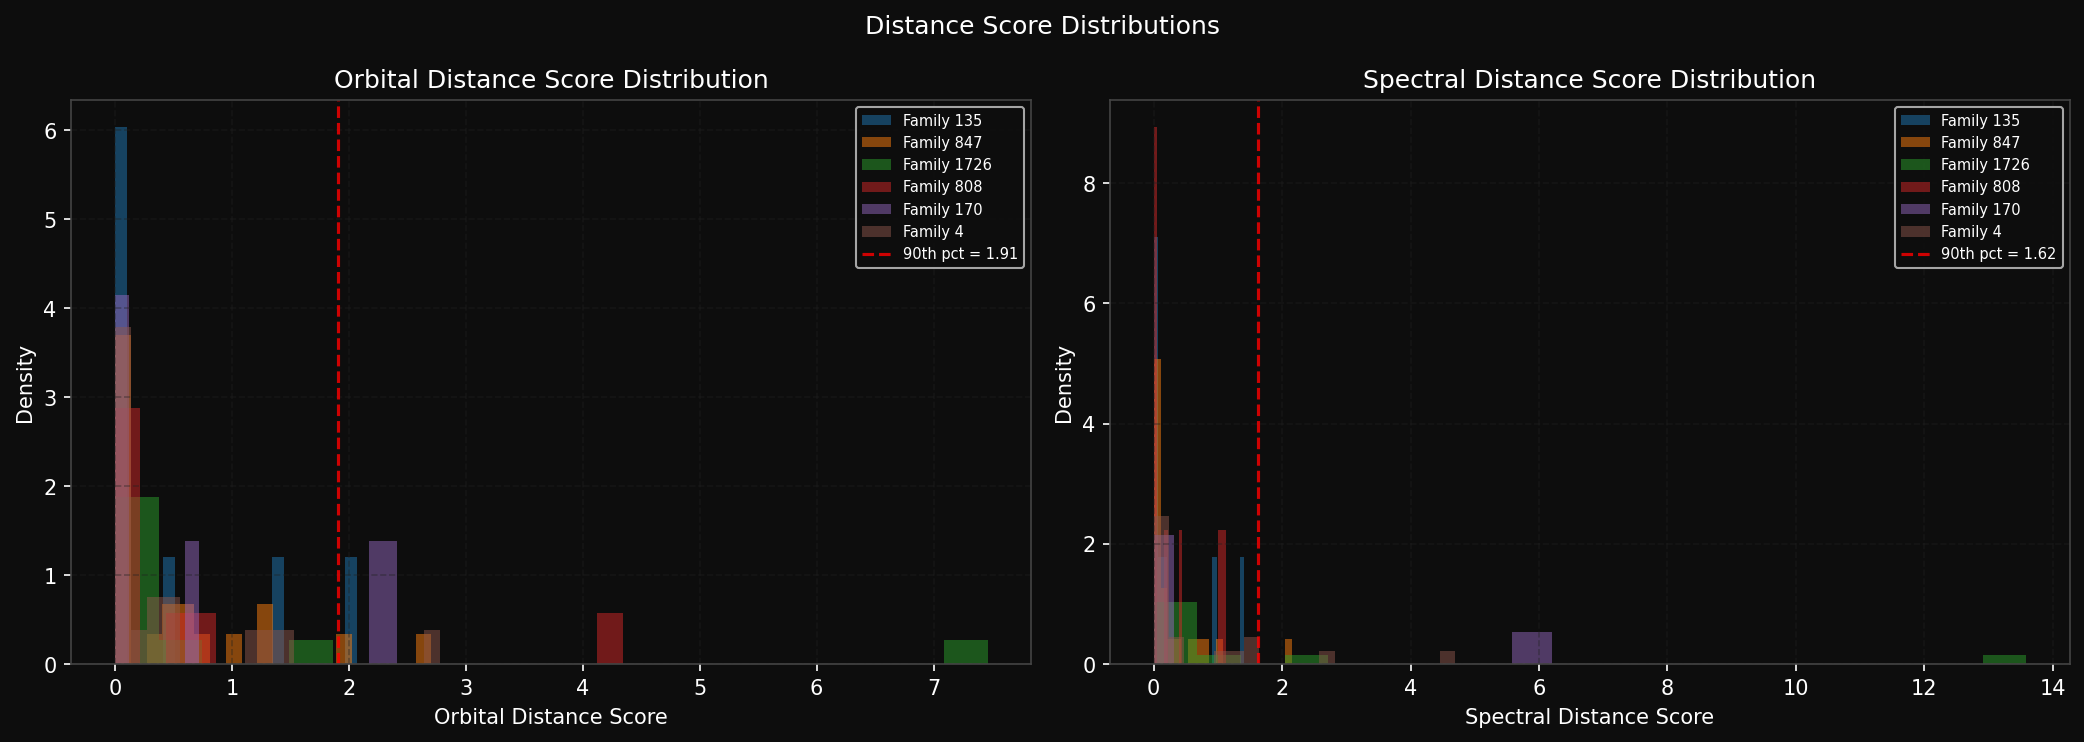

Orbital distance statistics:
count    73.000000
mean      0.621091
std       1.175087
min       0.000000
25%       0.000000
50%       0.000000
75%       0.674491
max       7.462117
Name: orbital_distance, dtype: float64

Orbital percentiles:
0.50    0.000000
0.75    0.674491
0.90    1.910179
0.95    2.528647
0.99    5.214718
Name: orbital_distance, dtype: float64

Spectral distance statistics:
count    73.000000
mean      0.745871
std       1.942374
min       0.000000
25%       0.000000
50%       0.000000
75%       0.722993
max      13.587883
Name: spectral_distance, dtype: float64

Spectral percentiles:
0.50    0.000000
0.75    0.722993
0.90    1.624392
0.95    3.565831
0.99    8.266626
Name: spectral_distance, dtype: float64


In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

orb_thresh_global = np.percentile(
    interloper_df['orbital_distance'],
    90
)

spec_thresh_global = np.percentile(
    interloper_df['spectral_distance'],
    90
)

for ax, col, label, thresh in zip(
    axes,
    ['orbital_distance', 'spectral_distance'],
    ['Orbital Distance Score', 'Spectral Distance Score'],
    [orb_thresh_global, spec_thresh_global]
):

    for fam_id in target_families:
        fam_data = interloper_df[
            interloper_df['family_1'] == fam_id
        ]

        ax.hist(
            fam_data[col],
            bins=20,
            alpha=0.5,
            density=True,
            label=f'Family {fam_id}'
        )

    ax.axvline(
        thresh,
        color='red',
        linestyle='--',
        alpha=0.8,
        label=f'90th pct = {thresh:.2f}'
    )

    ax.set_xlabel(label)
    ax.set_ylabel('Density')
    ax.set_title(f'{label} Distribution')
    ax.grid(True)
    ax.legend(fontsize=7)

plt.suptitle(
    'Distance Score Distributions',
    fontsize=12
)

plt.tight_layout()
plt.show()


print("Orbital distance statistics:")
print(interloper_df['orbital_distance'].describe())

print("\nOrbital percentiles:")
print(interloper_df['orbital_distance'].quantile(
    [0.50, 0.75, 0.90, 0.95, 0.99]
))

print("\nSpectral distance statistics:")
print(interloper_df['spectral_distance'].describe())

print("\nSpectral percentiles:")
print(interloper_df['spectral_distance'].quantile(
    [0.50, 0.75, 0.90, 0.95, 0.99]
))

# plt.savefig(os.path.join(plots_path, '04_threshold_check.png'),
#             dpi=200, bbox_inches='tight')

                Name  family_1 Bus Class  anomaly_score  \
34     4516 Pugovkin      1726        Sa       8.196894   
52           1996 UK       170        Sq       2.497081   
51           1996 PW       170        Ld       2.440031   
56       556 Phyllis         4         S       2.249165   
55        63 Ausonia         4        Sa       2.193088   
41      1327 Namaqua       808         X       2.074374   
27  7056 Kierkegaard       847        Sq       1.202827   
21   4917 Yurilvovia       847        Ld       1.194987   
70       5108 Lubeck         4         S       1.012829   
24      5840 1978 ON       847        Ld       1.004162   
7      4817 1984 DC1       135        Sl       0.974703   
49    897 Lysistrata       170        Sl       0.943623   
33      4124 Herriot      1726         B       0.909364   
4      2509 Chukotka       135         C       0.888540   
12        3349 Manas       847         L       0.829247   

                    anomaly_class  
34    Strong interl

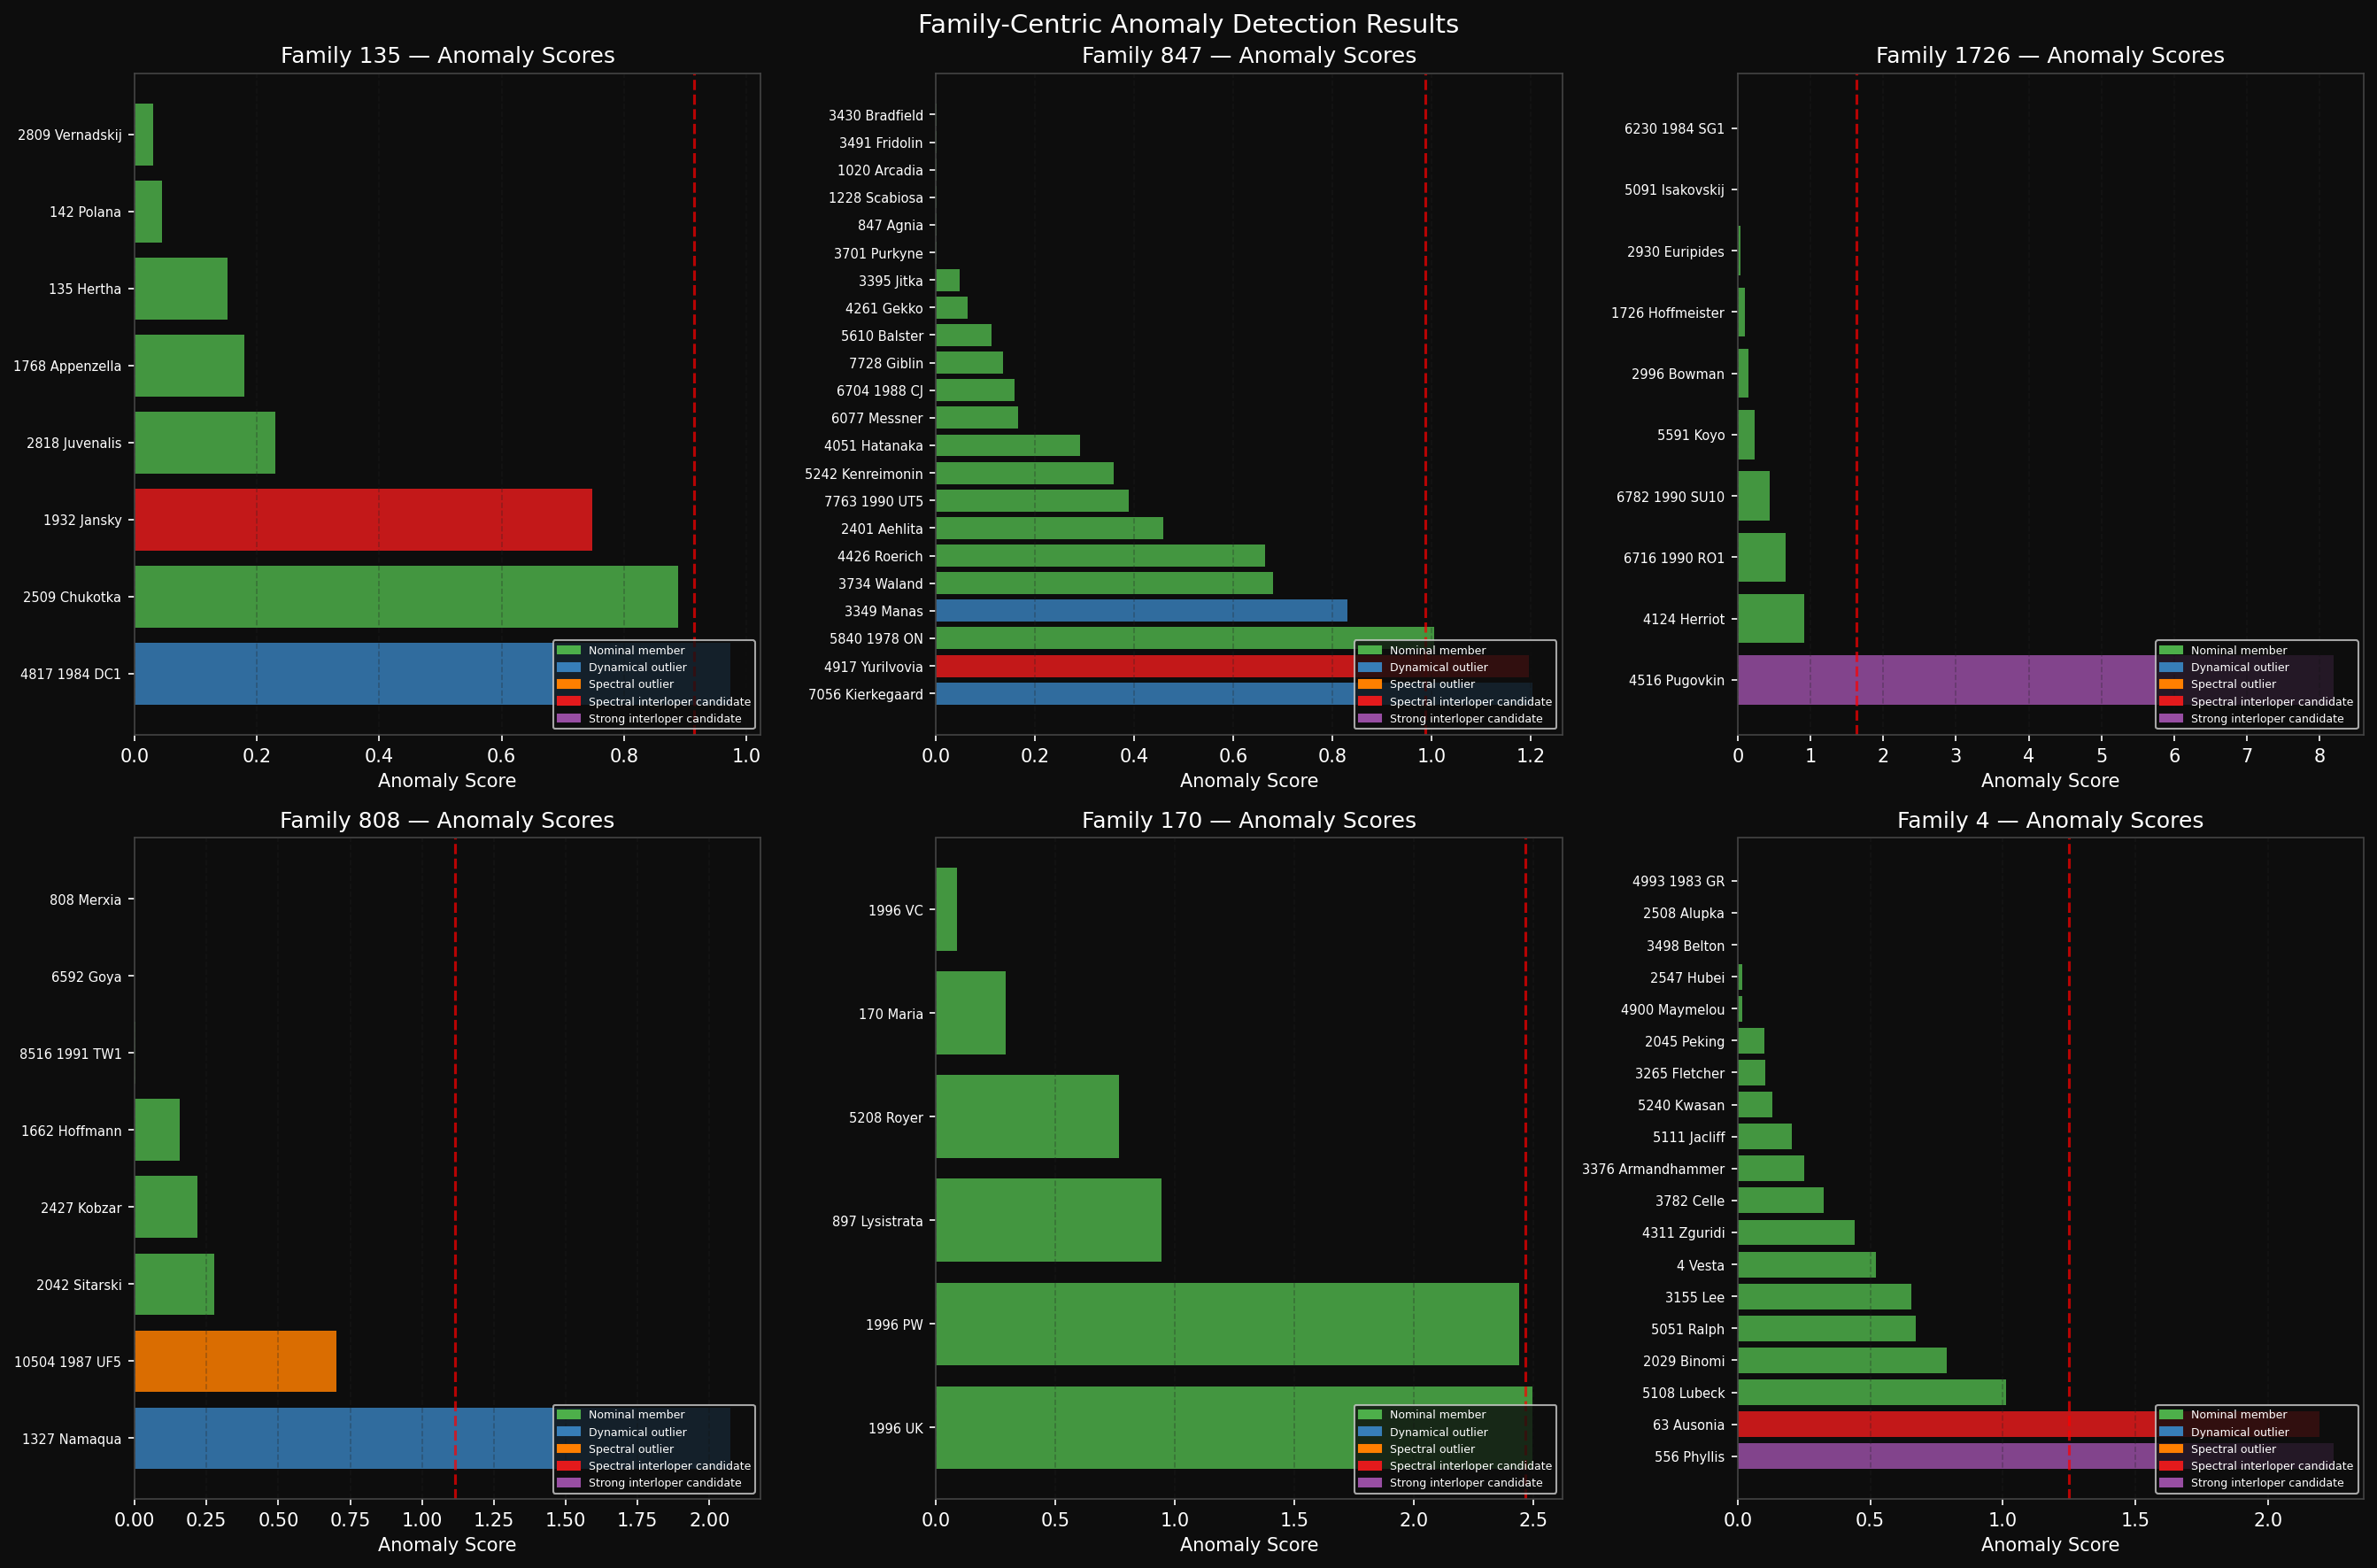

In [50]:
import matplotlib.patches as mpatches

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

anomaly_colors = {
    'Nominal member'                : '#4daf4a',
    'Dynamical outlier'             : '#377eb8',
    'Spectral outlier'              : '#ff7f00',
    'Spectral interloper candidate' : '#e41a1c',
    'Strong interloper candidate'   : '#984ea3',
}

for ax, fam_id in zip(axes, target_families):

    fam_data = (
        interloper_df[
            interloper_df['family_1'] == fam_id
        ]
        .copy()
        .sort_values(
            'anomaly_score',
            ascending=False
        )
    )

    summary = (
        interloper_df
        .sort_values('anomaly_score', ascending=False)
        [['Name',
        'family_1',
        'Bus Class',
        'anomaly_score',
        'anomaly_class']]
    )
    
    colors_ = fam_data['anomaly_class'].map(
        anomaly_colors
    )

    ax.barh(
        range(len(fam_data)),
        fam_data['anomaly_score'],
        color=colors_,
        edgecolor='none',
        alpha=0.85
    )

    ax.set_yticks(range(len(fam_data)))
    ax.set_yticklabels(
        fam_data['Name'].values,
        fontsize=7
    )

    # Highlight family-specific top anomalies
    p90 = np.percentile(
        fam_data['anomaly_score'],
        90
    )

    ax.axvline(
        p90,
        color='red',
        linestyle='--',
        alpha=0.7,
        label=f'90th pct ({p90:.2f})'
    )

    ax.set_xlabel('Anomaly Score')
    ax.set_title(
        f'Family {fam_id} — Anomaly Scores'
    )

    ax.grid(
        True,
        axis='x',
        alpha=0.3
    )

    patches = [
        mpatches.Patch(
            color=c,
            label=l
        )
        for l, c in anomaly_colors.items()
    ]

    ax.legend(
        handles=patches,
        fontsize=6,
        loc='lower right'
    )


print(summary.head(15))

# Hide unused panels
for ax in axes[len(target_families):]:
    ax.set_visible(False)

plt.suptitle(
    'Family-Centric Anomaly Detection Results',
    fontsize=14
)

plt.tight_layout()
plt.show()

# plt.savefig(os.path.join(plots_path, '04_anomaly_scores.png'),
#             dpi=200, bbox_inches='tight')

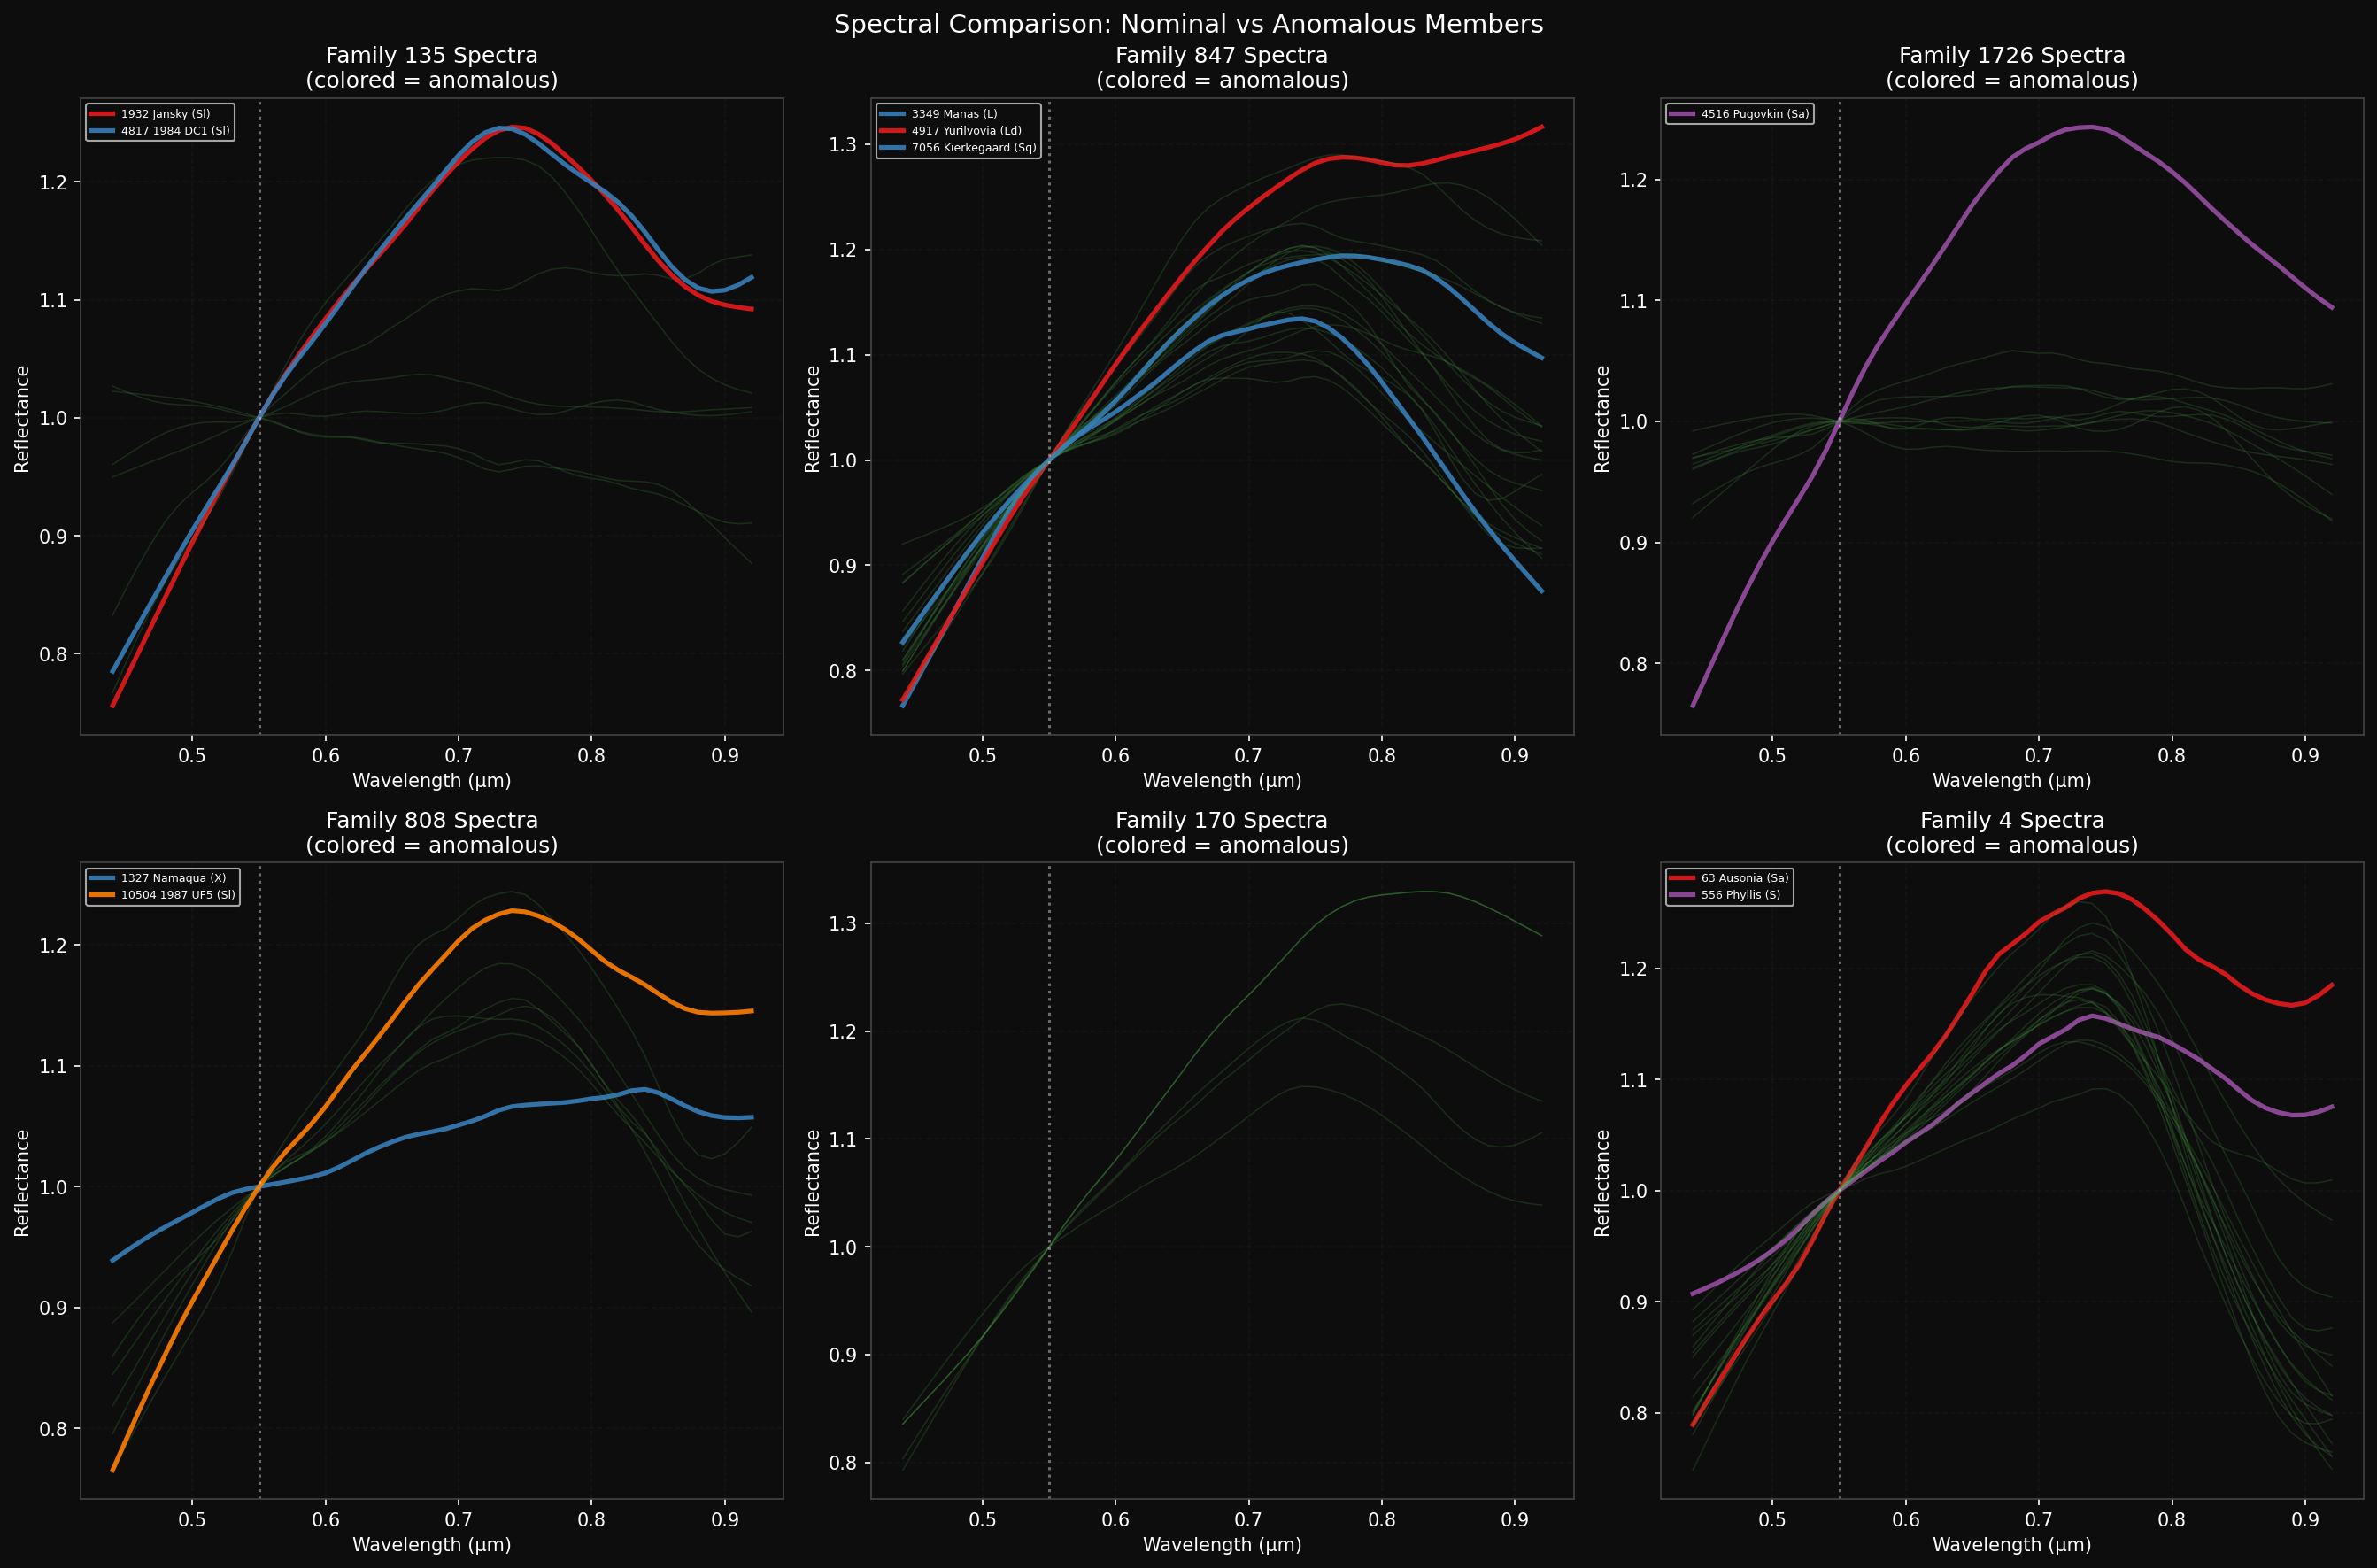

In [54]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for ax, fam_id in zip(axes, target_families):

    fam_data = interloper_df[
        interloper_df['family_1'] == fam_id
    ]

    for _, row in fam_data.iterrows():

        idx = unified_df[
            unified_df['Asteroid_id']
            == row['Asteroid_id']
        ].index

        if len(idx) == 0:
            continue

        idx = idx[0]

        spectrum = spectra_matrix[idx]

        color = anomaly_colors.get(
            row['anomaly_class'],
            'white'
        )

        is_anomalous = (
            row['anomaly_class']
            != 'Nominal member'
        )

        alpha = 0.90 if is_anomalous else 0.20
        lw    = 2.5  if is_anomalous else 0.75

        label = (
            f"{row['Name']} "
            f"({row['Bus Class']})"
            if is_anomalous
            else None
        )

        ax.plot(
            wavelengths,
            spectrum,
            color=color,
            alpha=alpha,
            linewidth=lw,
            label=label
        )

    ax.axvline(
        0.55,
        color='white',
        linestyle=':',
        alpha=0.4
    )

    ax.set_xlabel('Wavelength (μm)')
    ax.set_ylabel('Reflectance')

    ax.set_title(
        f'Family {fam_id} Spectra\n'
        f'(colored = anomalous)'
    )

    ax.grid(True, alpha=0.3)

    handles, labels = ax.get_legend_handles_labels()

    if len(handles) > 0:
        ax.legend(
            fontsize=6,
            loc='upper left'
        )

for ax in axes[len(target_families):]:
    ax.set_visible(False)

plt.suptitle(
    'Spectral Comparison: Nominal vs Anomalous Members',
    fontsize=14
)

plt.tight_layout()
plt.show()
# plt.savefig(os.path.join(plots_path, '04_spectra_comparison.png'),
#             dpi=200, bbox_inches='tight')

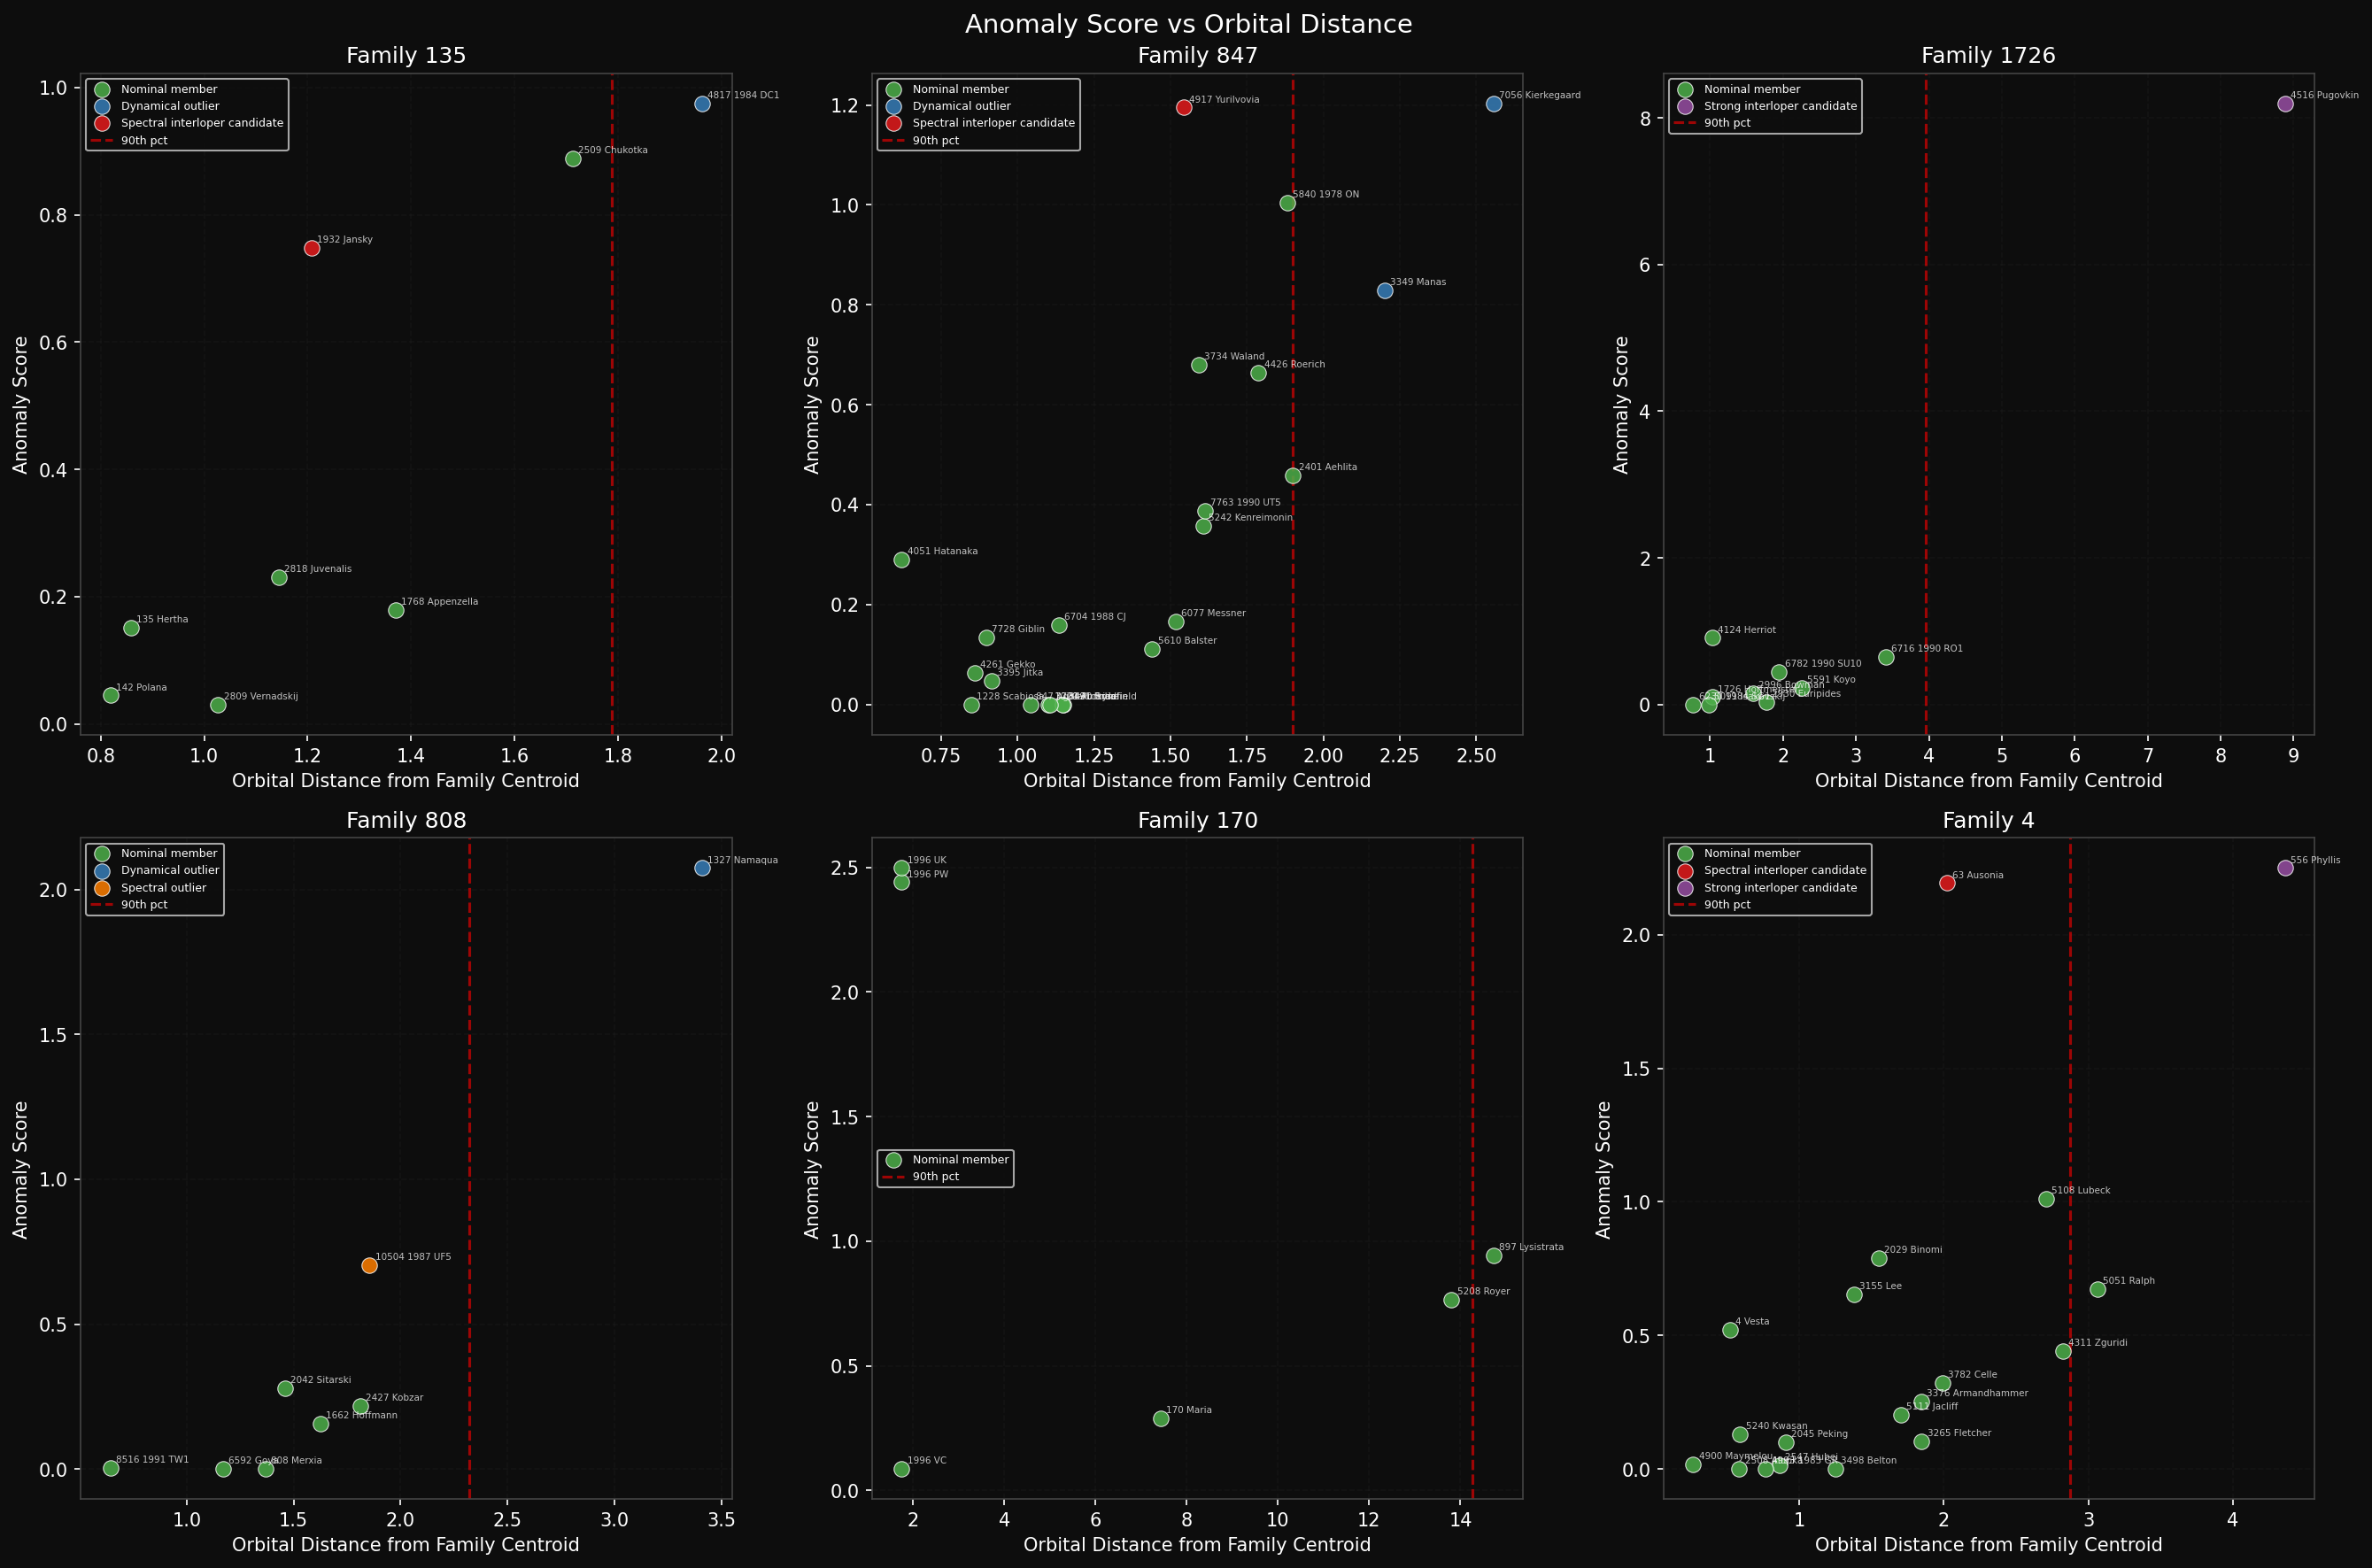

In [55]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for ax, fam_id in zip(axes, target_families):

    fam_data = interloper_df[
        interloper_df['family_1'] == fam_id
    ]

    for cls, color in anomaly_colors.items():

        mask = (
            fam_data['anomaly_class']
            == cls
        )

        if mask.sum() == 0:
            continue

        ax.scatter(
            fam_data.loc[mask, 'orbital_distance_raw'],
            fam_data.loc[mask, 'anomaly_score'],
            s=70,
            c=color,
            alpha=0.85,
            label=cls,
            edgecolors='white',
            linewidths=0.5,
            zorder=3
        )

        for _, row in fam_data[mask].iterrows():

            ax.annotate(
                row['Name'],
                (
                    row['orbital_distance_raw'],
                    row['anomaly_score']
                ),
                fontsize=5,
                color='white',
                alpha=0.75,
                xytext=(3, 3),
                textcoords='offset points'
            )

    # family-specific threshold
    orb_thresh = np.percentile(
        fam_data['orbital_distance_raw'],
        90
    )

    ax.axvline(
        orb_thresh,
        color='red',
        linestyle='--',
        alpha=0.6,
        label='90th pct'
    )

    ax.set_xlabel(
        'Orbital Distance from Family Centroid'
    )

    ax.set_ylabel(
        'Anomaly Score'
    )

    ax.set_title(
        f'Family {fam_id}'
    )

    ax.grid(True, alpha=0.3)

    ax.legend(fontsize=6)

for ax in axes[len(target_families):]:
    ax.set_visible(False)

plt.suptitle(
    'Anomaly Score vs Orbital Distance',
    fontsize=14
)

plt.tight_layout()
plt.show()
# plt.savefig(os.path.join(plots_path, '04_anomaly_vs_dv.png'),
#             dpi=200, bbox_inches='tight')

In [59]:
# Full interloper catalog — all flagged asteroids
interloper_catalog = interloper_df[
    interloper_df['anomaly_class'] != 'Nominal member'
][[
    'Name',
    'Bus Class',
    'Spectral_Complex',
    'family_1',
    'a_p',
    'e_p',
    'sin_i_p',
    'rms_a',
    'LCE',
    'orbital_distance_raw',
    'spectral_distance_raw',
    'anomaly_score',
    'anomaly_class'
]].copy()

interloper_catalog = interloper_catalog.sort_values(
    ['anomaly_score'], ascending=[False]
)

print("=" * 75)
print("INTERLOPER CATALOG")
print("=" * 75)
print(f"Total flagged asteroids : {len(interloper_catalog):,}")
print(f"\nBy anomaly class:")
print(interloper_catalog['anomaly_class'].value_counts().to_string())
print(f"\nBy family:")
print(interloper_catalog.groupby('family_1')['anomaly_class']
      .value_counts().to_string())

print(f"\n\nFull catalog:")
print(interloper_catalog.to_string())

INTERLOPER CATALOG
Total flagged asteroids : 10

By anomaly class:
anomaly_class
Dynamical outlier                4
Spectral interloper candidate    3
Strong interloper candidate      2
Spectral outlier                 1

By family:
family_1  anomaly_class                
4         Spectral interloper candidate    1
          Strong interloper candidate      1
135       Dynamical outlier                1
          Spectral interloper candidate    1
808       Dynamical outlier                1
          Spectral outlier                 1
847       Dynamical outlier                2
          Spectral interloper candidate    1
1726      Strong interloper candidate      1


Full catalog:
                Name Bus Class Spectral_Complex  family_1       a_p       e_p   sin_i_p         rms_a    LCE  orbital_distance_raw  spectral_distance_raw  anomaly_score                  anomaly_class
34     4516 Pugovkin        Sa        S-complex      1726  2.777637  0.046043  0.081175  0.000000e+00   1.

In [ ]:
print("=" * 70)
print("INTERLOPER DETECTION — FINAL SUMMARY")
print("=" * 70)

total_analyzed = len(interloper_df)

class_counts = (
    interloper_df['anomaly_class']
    .value_counts()
)

print(f"\nTotal asteroids analyzed : {total_analyzed}")

for cls, count in class_counts.items():
    print(
        f"{cls:<30} : "
        f"{count:>3} "
        f"({100*count/total_analyzed:5.1f}%)"
    )

total_flagged = (
    total_analyzed
    - class_counts.get('Nominal member', 0)
)

print(
    f"\nTotal flagged (non-nominal) : "
    f"{total_flagged} "
    f"({100*total_flagged/total_analyzed:.1f}%)"
)

print("\nContamination rate by tier:")

for tier, families in [
    (1, tier1_families),
    (2, tier2_families)
]:

    tier_data = interloper_df[
        interloper_df['family_1'].isin(families)
    ]

    if len(tier_data) == 0:
        continue

    n_nominal = (
        tier_data['anomaly_class']
        == 'Nominal member'
    ).sum()

    contamination = (
        100 *
        (1 - n_nominal / len(tier_data))
    )

    print(
        f"  Tier {tier}: "
        f"{contamination:5.1f}% flagged "
        f"({len(tier_data)} asteroids, "
        f"{len(families)} families)"
    )

print("\nTop anomaly candidates:")

top_candidates = (
    interloper_df
    .sort_values(
        'anomaly_score',
        ascending=False
    )
    .head(10)
)

print(
    top_candidates[
        [
            'Name',
            'family_1',
            'Bus Class',
            'Spectral_Complex',
            'anomaly_score',
            'anomaly_class'
        ]
    ].to_string(index=False)
)

INTERLOPER DETECTION — FINAL SUMMARY

Total asteroids analyzed : 73
Nominal member                 :  63 ( 86.3%)
Dynamical outlier              :   4 (  5.5%)
Spectral interloper candidate  :   3 (  4.1%)
Strong interloper candidate    :   2 (  2.7%)
Spectral outlier               :   1 (  1.4%)

Total flagged (non-nominal) : 10 (13.7%)

Contamination rate by tier:
  Tier 1:  16.7% flagged (30 asteroids, 2 families)
  Tier 2:  11.6% flagged (43 asteroids, 4 families)

Top anomaly candidates:
            Name  family_1 Bus Class Spectral_Complex  anomaly_score                 anomaly_class
   4516 Pugovkin      1726        Sa        S-complex       8.196894   Strong interloper candidate
         1996 UK       170        Sq        S-complex       2.497081                Nominal member
         1996 PW       170        Ld           L-type       2.440031                Nominal member
     556 Phyllis         4         S        S-complex       2.249165   Strong interloper candidate
      6

In [60]:
interloper_df.to_pickle(
    os.path.join(results_path, '04_interloper_results.pkl')
)
interloper_catalog.to_csv(
    os.path.join(results_path, '04_interloper_catalog.csv'),
    index=False
)

print("Saved:")
print("  → data/results/04_interloper_results.pkl")
print("  → data/results/04_interloper_catalog.csv")

Saved:
  → data/results/04_interloper_results.pkl
  → data/results/04_interloper_catalog.csv
